# **Build Custom Object Detector with Detectron2**

<img src="https://dl.fbaipublicfiles.com/detectron2/Detectron2-Logo-Horz.png" width="500">

# **Installing Roboflow for Dataset**

In [ ]:
!pip install roboflow

# **Installing Detectron**

In [ ]:
!!!!python -m pip install pyyaml==5.1

import sys,os,distutils.core

# Note: This is a faster way to install detectron2 in Colab, but it does not include all functionalities (e.g. compiled operators).
# See https://detectron2.readthedocs.io/tutorials/install.html for full installation instructions
!git clone 'https://github.com/facebookresearch/detectron2'

dist = distutils.core.run_setup("./detectron2/setup.py")

!python -m pip install {' '.join([f"'{x}'" for x in dist.install_requires])}
sys.path.insert(0,os.path.abspath('./detectron2'))

fatal: destination path 'detectron2' already exists and is not an empty directory.
Ignoring dataclasses: markers 'python_version < "3.7"' don't match your environment


In [ ]:
import torch,detectron2
!nvcc --version

print(f"\nTORCH VERSION: {".".join(torch.__version__.split('.')[:2])} \nCUDA_VERSION: {torch.__version__.split("+")[-1]} \nDTECTRON_VERSION: {detectron2.__version__}")

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0

TORCH VERSION: 2.11 
CUDA_VERSION: cu128 
DTECTRON_VERSION: 0.6


- **IMPORTS LIBRARY**

In [ ]:
# Some basic setup:
# Setup detectron2 logger
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()

# import some common library
import numpy as np
import json,os,cv2,random
from google.colab.patches import cv2_imshow
import warnings
warnings.filterwarnings('ignore')

# Import some common Library
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer

from detectron2.data import MetadataCatalog,DatasetCatalog

- **Let's get Our Dataset**

- **[DATASET LINK](https://universe.roboflow.com/roboflow-universe-projects/fire-and-smoke-segmentation/dataset/6#)**

In [ ]:
from google.colab import userdata
api_key = userdata.get('RF')


from roboflow import Roboflow
rf = Roboflow(api_key=api_key)
project = rf.workspace("roboflow-universe-projects").project("fire-and-smoke-segmentation")
version = project.version(6)
dataset = version.download("coco-segmentation")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Fire-and-Smoke-Segmentation-6 in coco-segmentation:: 100%|██████████| 7118/7118 [00:01<00:00, 3705.49it/s]


In [ ]:
!pwd

/content


In [ ]:
%cd /content/Fire-and-Smoke-Segmentation-6

/content/Fire-and-Smoke-Segmentation-6


In [ ]:
!pwd

/content/Fire-and-Smoke-Segmentation-6


In [ ]:
!cat /content/Fire-and-Smoke-Segmentation-6/test/_annotations.coco.json

{"info":{"year":"2025","version":"6","description":"Exported from roboflow.com","contributor":"","url":"https://public.roboflow.com/object-detection/undefined","date_created":"2025-04-11T08:34:26+00:00"},"licenses":[{"id":1,"url":"https://creativecommons.org/licenses/by/4.0/","name":"CC BY 4.0"}],"categories":[{"id":0,"name":"fire-smoke","supercategory":"none"},{"id":1,"name":"fire","supercategory":"fire-smoke"},{"id":2,"name":"smoke","supercategory":"fire-smoke"}],"images":[{"id":0,"license":1,"file_name":"flare_0074_jpg.rf.aa3d148ea4d6689f69e05e44cbb15ca5.jpg","height":640,"width":640,"date_captured":"2025-04-11T08:34:26+00:00","extra":{"user_tags":["cloned-universe","fire-smoke","polygon-labels"],"name":"flare_0074.jpg"}},{"id":1,"license":1,"file_name":"flare_0199_jpg.rf.ae500cc8937e810f0a400aec85299764.jpg","height":640,"width":640,"date_captured":"2025-04-11T08:34:26+00:00","extra":{"user_tags":["cloned-universe","fire-smoke","polygon-labels"],"name":"flare_0199.jpg"}},{"id":2,"l

- **Register Dataset**

In [ ]:
from detectron2.data.datasets import register_coco_instances

register_coco_instances("exp_train",{},"/content/Fire-and-Smoke-Segmentation-6/train/_annotations.coco.json","/content/Fire-and-Smoke-Segmentation-6/train")
register_coco_instances("exp_valid",{},"/content/Fire-and-Smoke-Segmentation-6/valid/_annotations.coco.json","/content/Fire-and-Smoke-Segmentation-6/valid")
register_coco_instances("exp_test",{},"/content/Fire-and-Smoke-Segmentation-6/test/_annotations.coco.json","/content/Fire-and-Smoke-Segmentation-6/test")

- **Visualize training data**

WARNING [09/10 08:44:13 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[09/10 08:44:13 d2.data.datasets.coco]: Loaded 7050 images in COCO format from /content/Fire-and-Smoke-Segmentation-6/train/_annotations.coco.json


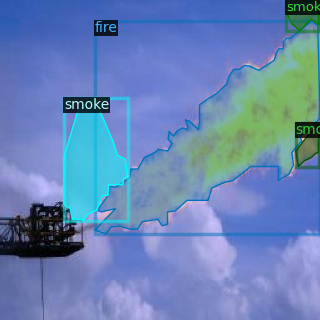

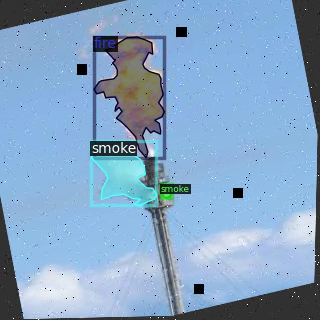

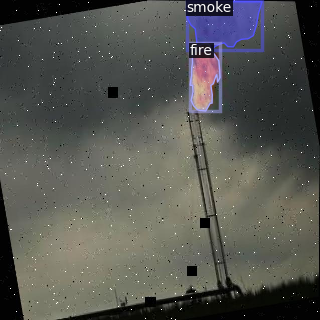

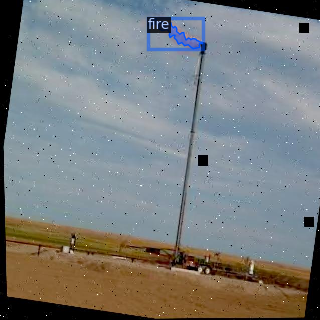

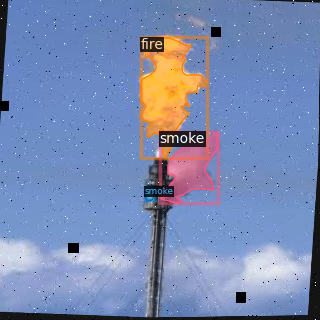

In [ ]:
train_metadata = MetadataCatalog.get("exp_train")
dataset_dict = DatasetCatalog.get("exp_train")

import random
from detectron2.utils.visualizer import Visualizer

for d in random.sample(dataset_dict,5):
  im = cv2.imread(d['file_name'])
  v = Visualizer(im[:,:,::-1],metadata=train_metadata,scale=0.5)
  vis = v.draw_dataset_dict(d)
  cv2_imshow(vis.get_image()[:,:,::-1])

- **Training**

In [17]:
#Imports DefaultTrainer, which provides Detectron2's standard training pipeline.
from detectron2.engine import DefaultTrainer

#Creates a Detectron2 configuration object to store all training settings.
cfg = get_cfg()

# Loads the predefined Faster R-CNN R50-FPN 3x model configuration from Detectron2 Model Zoo.
cfg.merge_from_file(model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"))

#Specifies exp_valid as the dataset used for training.
cfg.DATASETS.TRAIN = 'exp_train'
# Specifies exp_valid as the dataset used for testing/validation during training.
cfg.DATASETS.TEST = ('exp_valid',)

#Uses 2 CPU worker processes to load training images
cfg.DATALOADER.NUM_WORKERS = 2

#Loads pretrained COCO weights as the starting point for training.
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml")

#Processes 2 images per training iteration (batch).
cfg.SOLVER.IMS_PER_BATCH = 2

#Sets the initial learning rate to 0.0025.
cfg.SOLVER.BASE_LR = 0.0025

#Trains the model for a maximum of 1000 iterations.
cfg.SOLVER.MAX_ITER = 1000

# Clear SOLVER.STEPS to avoid warning about steps exceeding MAX_ITER for short training runs.
cfg.SOLVER.STEPS = ()

#Uses 128 sampled RoIs (regions) per image for training the ROI heads.
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128

#cfg.MODEL.DEVICE = 'cpu'

# Creates the model's output directory if it doesn't already exist
os.makedirs(cfg.OUTPUT_DIR,exist_ok=True)

#Creates a Detectron2 trainer using your configuration.
trainer = DefaultTrainer(cfg)

#Resumes training from an existing checkpoint if available; otherwise loads the configured pretrained weights.
trainer.resume_or_load(resume=True)

#Starts the actual model training.
trainer.train()

[09/10 09:06:32 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

In [19]:
cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR,"model_final.pth")
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5
cfg.DATASETS.TEST = ("exp_train",)
predictor = DefaultPredictor(cfg)

[09/10 09:12:21 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from ./output/model_final.pth ...


- **Visualizing Results**

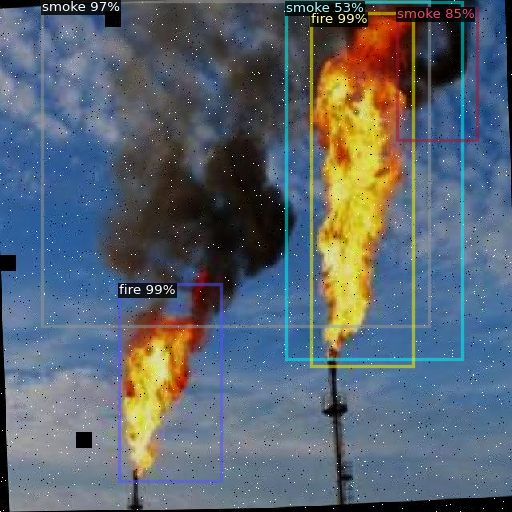

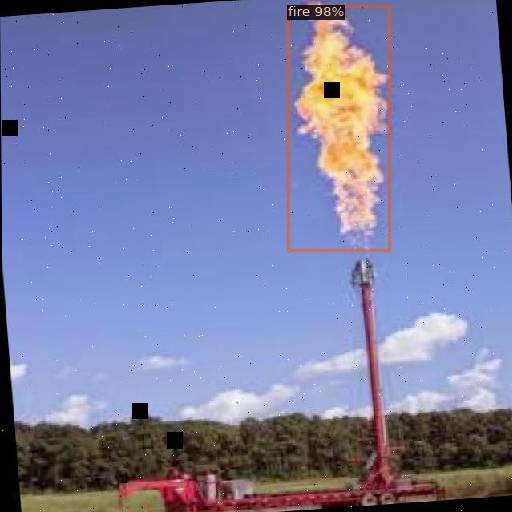

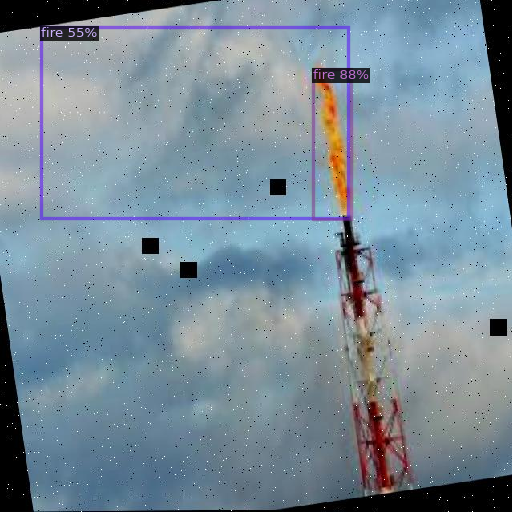

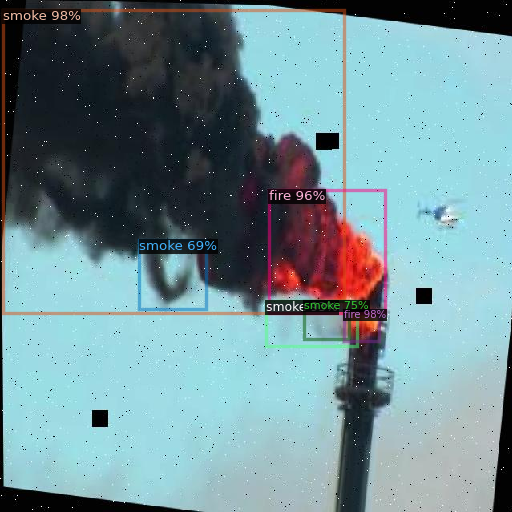

In [21]:
from detectron2.utils.visualizer import ColorMode

for d in random.sample(dataset_dict,4):
  im = cv2.imread(d['file_name'])
  outputs = predictor(im)
  v = Visualizer(
      im[:,:,::-1],
      metadata = train_metadata,
      scale=0.8,
      #instance_mode=ColorMode.IMAGE_BW   # remove the colors of unsegmented pixels
  )
  v = v.draw_instance_predictions(outputs['instances'].to('cpu'))
  cv2_imshow(v.get_image()[:,:,::-1])

- **EVALUATION**

In [22]:
from detectron2.evaluation import COCOEvaluator,inference_on_dataset
from detectron2.data import build_detection_test_loader

evaluator = COCOEvaluator("exp_test",output_dir="./output")
val_loader = build_detection_test_loader(cfg,"exp_test")
print(inference_on_dataset(predictor.model,val_loader,evaluator))

[09/10 09:19:42 d2.evaluation.coco_evaluation]: Fast COCO eval is not built. Falling back to official COCO eval.
WARNING [09/10 09:19:42 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[09/10 09:19:42 d2.data.datasets.coco]: Loaded 20 images in COCO format from /content/Fire-and-Smoke-Segmentation-6/test/_annotations.coco.json
[09/10 09:19:42 d2.data.build]: Distribution of instances among all 3 categories:
|  category  | #instances   |  category  | #instances   |  category  | #instances   |
|:----------:|:-------------|:----------:|:-------------|:----------:|:-------------|
| fire-smoke | 0            |    fire    | 29           |   smoke    | 19           |
|            |              |            |              |            |              |
|   total    | 48           |            |              |            |              |
[09/10 09:19:42 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [Re

- **Getting the custom config file**

In [23]:
f = open('conig.yaml','w')
f.write(cfg.dump())
f.close()